# Libreria Pandas

### - Permette di caricare, manipolare e visualizzare dati sequenziali e tabellari
### - Si basa su due costrutti fondamentali: <font color="red">Series</font> e <font color="red">DataFrame</font>

In [1]:
# Importa la libreria Pandas
import numpy as np # Pandas si appoggia a numpy
import pandas as pd
from pandas import Series, DataFrame # permette di scrivere direttamente Series al posto di pd.Series

## Series

### Una Serie è un array monodimensionale, con un insieme Index che può essere usato per accedere agli elementi e che può contenere oggetti di qualsiasi tipo numpy

### Creazione di una serie senza specificare l'insieme Index

In [2]:
serie1 = Series(["primo elemento", "secondo elemento", 1000])

In [4]:
print(serie1)

0      primo elemento
1    secondo elemento
2                1000
dtype: object


In [5]:
print(serie1.index)
print(serie1.values)
print(serie1[1])

RangeIndex(start=0, stop=3, step=1)
['primo elemento' 'secondo elemento' 1000]
secondo elemento


### Creazione di una serie specificando l'insieme Index

In [6]:
giudizi = Series(["buono", "sufficiente", "ottimo"], index=["Antonio", "Giovanni", "Federica"])

In [7]:
print(giudizi, "\n")
print(giudizi.index, "\n")
print(giudizi.values, "\n")
print(giudizi[0], "\n")
print(giudizi["Giovanni"])

Antonio           buono
Giovanni    sufficiente
Federica         ottimo
dtype: object 

Index(['Antonio', 'Giovanni', 'Federica'], dtype='object') 

['buono' 'sufficiente' 'ottimo'] 

buono 

sufficiente


### L'insieme index può anche essere valorizzato a posteriori

In [ ]:
serie1.index = ["Index1", "Index2", "Index3"]

In [ ]:
print(serie1)

### Si può creare una Serie anche utilizzando un dictionary, l'insieme Index è composto dalle chiavi del dict

In [8]:
settimana = {"Primo Giorno": "Lun", "Secondo Giorno": "Mar", "Terzo Giorno": "Mer", 
             "Quarto Giorno": "Giov", "Quinto Giorno": "Ven", "Sesto Giorno": "Sab", "Settimo Giorno": "Dom"}

In [9]:
Sett = Series(settimana)

In [10]:
print(Sett)

Primo Giorno       Lun
Secondo Giorno     Mar
Terzo Giorno       Mer
Quarto Giorno     Giov
Quinto Giorno      Ven
Sesto Giorno       Sab
Settimo Giorno     Dom
dtype: object


### I primi n e gli ultimi n elementi possono essere estratti con head(n) e tail(n)

In [11]:
GiorniLav = Sett.head(5)
print(GiorniLav)

Primo Giorno       Lun
Secondo Giorno     Mar
Terzo Giorno       Mer
Quarto Giorno     Giov
Quinto Giorno      Ven
dtype: object


In [12]:
WeekEnd =Sett.tail(2)
print(WeekEnd)

Sesto Giorno      Sab
Settimo Giorno    Dom
dtype: object


### Sulle serie si possono fare tutte le operazioni previste per gli array. Se a un indice non corrisponde alcun valore questi sarà contrassegnato da NaN (not a number)

In [16]:
voti1 = {"Mario":6, "Massimo":4, "Elena":5, "Fabio":10}
voti2 = {"Mario":4, "Massimo":6, "Elena":3, "Fabio":6}
serie1 = Series(voti1)
serie2 = Series(voti2)
serieSomma = serie1 + serie2
print(serie1, "\n")
print(serie2, "\n")
print(serieSomma, "\n")

Mario       6
Massimo     4
Elena       5
Fabio      10
dtype: int64 

Mario      4
Massimo    6
Elena      3
Fabio      6
dtype: int64 

Mario      10
Massimo    10
Elena       8
Fabio      16
dtype: int64 



### Che succede se sommo due serie con indici non tutti uguali?

In [17]:
voti3 = {"Mario":4, "Massimo":6, "Elena":3, "Rosa":6}
serie3 = Series(voti3)
newSerieSomma = serie1 + serie2 + serie3
print(newSerieSomma)

Elena      11.0
Fabio       NaN
Mario      14.0
Massimo    16.0
Rosa        NaN
dtype: float64


### - Series.get(key, default=None) consente di sapere se un'etichetta non ha valore
### - Series.dropna elimina i valori mancanti
### - Series.fillna(valore) sostituisce i valori mancanti con un valore specifico
### - Series.add (..) può sostituire il valore Nan con un valore indicato

In [18]:
serieSommaSenzaNa = newSerieSomma.dropna()
print(serieSommaSenzaNa, "\n")
print(newSerieSomma)

Elena      11.0
Mario      14.0
Massimo    16.0
dtype: float64 

Elena      11.0
Fabio       NaN
Mario      14.0
Massimo    16.0
Rosa        NaN
dtype: float64


In [19]:
serieSommaConNone = newSerieSomma.fillna("senza valore")
print(serieSommaConNone)

Elena              11.0
Fabio      senza valore
Mario              14.0
Massimo            16.0
Rosa       senza valore
dtype: object


In [20]:
serieSomma = serie2 + serie3
print(serieSomma, "\n")
serieSomma = serie1.add(serie3, fill_value=0)
print(serieSomma, "\n")

Elena       6.0
Fabio       NaN
Mario       8.0
Massimo    12.0
Rosa        NaN
dtype: float64 

Elena       8.0
Fabio      10.0
Mario      10.0
Massimo    10.0
Rosa        6.0
dtype: float64 



In [21]:
# gli elementi di una serie si possono cisitare con il for
for index, value in serieSomma.items():
    print(index, value)

Elena 8.0
Fabio 10.0
Mario 10.0
Massimo 10.0
Rosa 6.0


### Operazioni sulle serie

In [14]:
d1 = {"Mario": 6, "Elena": 7, "Fabio": 5, "Giorgia": 10}
voti = Series(d1)
print(voti, "\n")
print("Somma voti ", voti.sum())
print("Produttoria voti ", voti.prod())
print("Voto maggiore ", voti.max())
print("Alunno più bravo ", voti.index[voti.argmax()])
print("Voto medio ", voti.mean())
print("Varianza ", voti.var())
print("Deviazione standard ", voti.std())
print("Voto mediano ", voti.median())
print("\n Lista ordinata \n", voti.sort_values(ascending = False))

Mario       6
Elena       7
Fabio       5
Giorgia    10
dtype: int64 

Somma voti  28
Produttoria voti  2100
Voto maggiore  10
Alunno più bravo  Giorgia
Voto medio  7.0
Varianza  4.666666666666667
Deviazione standard  2.160246899469287
Voto mediano  6.5

 Lista ordinata 
 Giorgia    10
Elena       7
Mario       6
Fabio       5
dtype: int64


## DataFrame

### I DataFrame sono Series a due dimensioni e rappresentano dati tabellari come un foglio elettronico contenente colonne di dati eterogenei

### Generazione di un DataFrame vuoto

In [ ]:
registro = DataFrame(columns = range(3), index = range(3))
print(registro)

In [ ]:
registro.index = ["Q1", "Q2", "Q3"]
registro.columns = ["Mario", "Elena", "Fabio"]
print(registro)

In [13]:
registro["Mario"] = [6, 8, 7]
registro["Elena"] = [6, 6, 7]
registro["Fabio"] = [ 5, 6, 6]
registro["Roberto"] = [7, 8, 8]
print(registro)

NameError: name 'registro' is not defined

### Per costruire un DataFrame è possibile usare dizionari

In [ ]:
prove = {"nome": ["Mario", "Mario", "Elena", "Elena", "Elena", "Fabio", "Fabio"],
         "quadrimestre": [1,2,1,2,3,2,3],
         "voto": [6,6,7,8,8,5,4]}
registro = DataFrame(prove)
print(registro)

### L'indice di colonna può essere cambiato (così come quello di riga)

In [ ]:
registro = DataFrame(prove, columns = ["quadrimestre", "nome", "voto", "sufficiente"])
print(registro)

In [ ]:
print(registro.columns, "\n")
print(registro.index, "\n")
print(registro.values, "\n")
print(registro.shape)
print(registro.nome)

In [ ]:
registro = DataFrame(prove, columns = ["quadrimestre", "nome", "voto", "sufficiente"],
                            index = ["primo el", "secondo el", "terzo el", "quarto el", "quinto el", "sesto el", "settimo el"])
print(registro)

### si possono aggiungere colonne attraverso le serie

In [ ]:
noteStudenti = Series([2, 1, 4], index=["secondo el", "terzo el", "quinto el"])
registro["note"] = noteStudenti
print(registro)

In [ ]:
# assegna un valore booleano alla colonna sufficiente
registro["sufficiente"] = registro.voto >= 6 
print(registro)

In [ ]:
# elimina la colonna note
del registro["note"]
print(registro)

### Per operare sugli indici si hanno a disposizione diversi metodi

In [22]:
i = pd.Index([1,3,4,5,7])
j = pd.Index([2,3,4,6])
print("append ", i.append(j))
print("differenza", i.difference(j))
print("intersezione", i.intersection(j))
print("unione", i.union(j))
print("è contenuto", i.isin([3,5]))
print("elimina", i.delete([1,2,4]))


append  Int64Index([1, 3, 4, 5, 7, 2, 3, 4, 6], dtype='int64')
differenza Int64Index([1, 5, 7], dtype='int64')
intersezione Int64Index([3, 4], dtype='int64')
unione Int64Index([1, 2, 3, 4, 5, 6, 7], dtype='int64')
è contenuto [False  True False  True False]
elimina Int64Index([1, 5], dtype='int64')


## Ordinamento di Series e DataFrame

### I DataFrame possono essere ordinati lungo i loro assi con sort_index (l'argomento ascending posto a False restituisce l'ordine decrescente)

In [24]:
studente = ["Mario", "Elena", "Fabio", "Rosa", "Giorgia"]
quadrimestre = ["Q2", "Q1", "Q3"]
voto = np.array([[6,7,5,2,6], [6,6,4,3,7], [5,8,6,8,9]])
tab = DataFrame(voto, columns = studente, index = quadrimestre)
print(tab)

    Mario  Elena  Fabio  Rosa  Giorgia
Q2      6      7      5     2        6
Q1      6      6      4     3        7
Q3      5      8      6     8        9


In [25]:
print(tab.sort_index())

    Mario  Elena  Fabio  Rosa  Giorgia
Q1      6      6      4     3        7
Q2      6      7      5     2        6
Q3      5      8      6     8        9


In [26]:
print(tab.sort_values(by="Mario"))

    Mario  Elena  Fabio  Rosa  Giorgia
Q3      5      8      6     8        9
Q2      6      7      5     2        6
Q1      6      6      4     3        7


In [27]:
print(tab.sort_values(by=["Mario", "Elena"]))

    Mario  Elena  Fabio  Rosa  Giorgia
Q3      5      8      6     8        9
Q1      6      6      4     3        7
Q2      6      7      5     2        6


In [28]:
print(tab.reindex(columns = ["Giorgia", "Mario", "Elena", "Fabio", "Rosa"]))

    Giorgia  Mario  Elena  Fabio  Rosa
Q2        6      6      7      5     2
Q1        7      6      6      4     3
Q3        9      5      8      6     8


## Grafici

### I dati di un DataFrame possono essere rappresentati graficamente usando la libreria matplotlib.pyplot

In [29]:
import matplotlib.pyplot as plt

# aggiunge una riga alla tabella

tab = tab.reindex(index = ["Q1", "Q2", "Q3", "Q4"])
tab["Mario"]["Q4"] = 6
tab["Elena"]["Q4"] = 8
tab["Rosa"]["Q4"] = 7
tab["Giorgia"]["Q4"] = 5

print(tab)

    Mario  Elena  Fabio  Rosa  Giorgia
Q1    6.0    6.0    4.0   3.0      7.0
Q2    6.0    7.0    5.0   2.0      6.0
Q3    5.0    8.0    6.0   8.0      9.0
Q4    6.0    8.0    NaN   7.0      5.0


<Axes: >

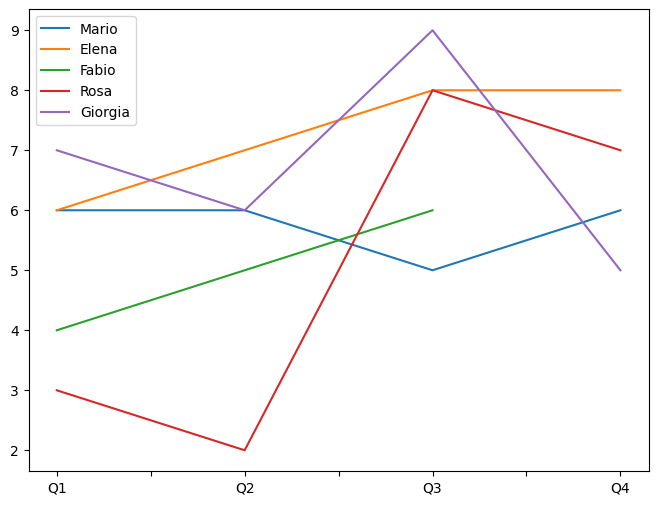

In [30]:
tab.plot(figsize=(8, 6))

<Axes: >

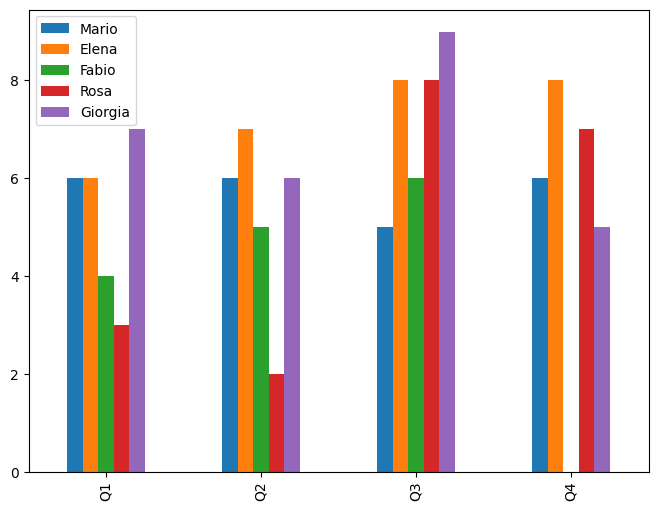

In [31]:

tab.plot(kind = "bar", figsize=(8, 6))

## Leggere e scrivere file xlsx con Pandas

In [ ]:
xlsx = pd.ExcelFile("TabellaProva.xlsx")

tab2 = pd.read_excel(xlsx, "Sheet1")
tab2


In [ ]:
tab2.Mario

In [ ]:
Quadr = tab2["Quadr."]
print(Quadr)

In [ ]:
del tab2["Quadr."]
print(tab2)

In [ ]:
tab2.index = Quadr
print(tab2)

In [ ]:
tab2["Mario"]

In [ ]:
tab.to_excel("TabellaProvaW.xlsx")